<a href="https://colab.research.google.com/github/Ivo-Islas/Procesos-Estocasticos-Medel/blob/main/catalogo_sympy.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Tarea: Matrices con Sympy y Grafos con NetworkX
**Alumno:** Islas Nava Ivo Abraham  
**Materia:** Procesos Estocásticos  
**Profesor:** Ricardo Medel

--- CÁLCULOS MATRICIALES ---


<IPython.core.display.Math object>

⎡2  0  0⎤
⎢       ⎥
⎢1  3  0⎥
⎢       ⎥
⎣0  1  1⎦

<IPython.core.display.Math object>

⎡1  -1  2 ⎤
⎢         ⎥
⎢0  1   -1⎥
⎢         ⎥
⎣1  0   1 ⎦

...

<IPython.core.display.Math object>

⎡4 ⎤
⎢  ⎥
⎢14⎥
⎢  ⎥
⎣10⎦

<IPython.core.display.Math object>

{1: 1, 2: 1, 3: 1}


--- REPRESENTACIÓN DEL GRAFO ---


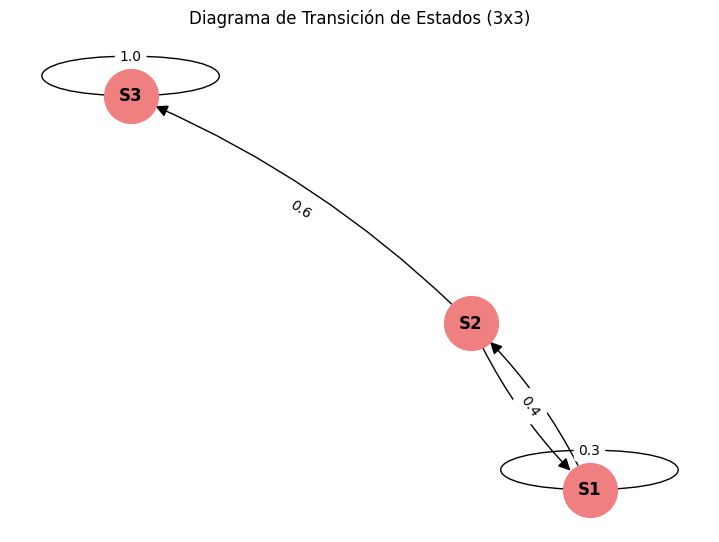

In [7]:
import sympy as sp
import networkx as nx
import matplotlib.pyplot as plt
from IPython.display import display, Math

# Formato matemático para Sympy
sp.init_printing(use_latex='mathjax')

# --- PARTE 1: OPERACIONES CON MATRICES (3x3) ---
# Definición de datos (matrices 3x3 y vector de 3x1)
m1 = sp.Matrix([[2, 0, 0], [1, 3, 0], [0, 1, 1]])
m2 = sp.Matrix([[1, -1, 2], [0, 1, -1], [1, 0, 1]])
vec = sp.Matrix([2, 4, 6])

# Cálculos rápidos
res_mult = m1 * m2
res_pot  = m1**3
res_vec  = m1 * vec

# Extracción de valores (renglón 0, columna 1 y entrada específica)
val_e = m1[0, 1]
row_0 = m1.row(0)

# Eigenvalores y Eigenvectores
evls = m1.eigenvals()
evct = m1.eigenvects()

# Impresión de resultados estructurada
print("--- CÁLCULOS MATRICIALES ---")
display(Math(r'M_1:'), m1)
display(Math(r'M_2:'), m2)  # <-- Aquí ya se muestra la segunda matriz
display(Math(rf'Entrada \ (0,1) \ de \ M_1: {val_e}'))
display(Math(r'Multiplicación \ (M_1 \cdot M_2):'), res_mult)
display(Math(r'Potencia \ (M_1^3):'), res_pot)
display(Math(r'Matriz \ por \ Vector \ (M_1 \cdot \vec{v}):'), res_vec)
display(Math(r'Eigenvalores \ de \ M_1 \ (val:mult):'), evls)

# --- PARTE 2: GRAFO DE TRANSICIÓN (3 Estados) ---
print("\n--- REPRESENTACIÓN DEL GRAFO ---")
dg = nx.DiGraph()

# Aristas del sistema (Origen, Destino, Probabilidad)
links = [
    ('S1', 'S1', 0.3), ('S1', 'S2', 0.7),
    ('S2', 'S1', 0.4), ('S2', 'S3', 0.6),
    ('S3', 'S3', 1.0) # Estado absorbente
]

for n1, n2, p in links:
    dg.add_edge(n1, n2, weight=p)

plt.figure(figsize=(7, 5))
coords = nx.spring_layout(dg)

# Dibujar elementos del diagrama
nx.draw(dg, coords, with_labels=True, node_color='lightcoral',
        node_size=1500, font_weight='bold', arrowsize=18,
        connectionstyle='arc3, rad = 0.1')

# Etiquetas de peso
w_labels = nx.get_edge_attributes(dg, 'weight')
nx.draw_networkx_edge_labels(dg, coords, edge_labels=w_labels)

plt.title("Diagrama de Transición de Estados (3x3)")
plt.axis('off')
plt.show()
